In [1]:
print("Project starts")

Project starts


In [2]:
!pip install yfinance seaborn scipy

   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ------------------ --------------------- 0.8/1.7 MB 4.3 MB/s eta 0:00:01
   ---------------------------------------- 1.7/1.7 MB 4.2 MB/s  0:00:00

   ---------------------------------------- 0/5 [peewee]
   ---------------------------------------- 0/5 [peewee]
   -------- ------------------------------- 1/5 [multitasking]
   ---------------- ----------------------- 2/5 [websockets]
   ---------------- ----------------------- 2/5 [websockets]
   ---------------- ----------------------- 2/5 [websockets]
   ------------------------ --------------- 3/5 [curl_cffi]
   ------------------------ --------------- 3/5 [curl_cffi]
   ------------------------ --------------- 3/5 [curl_cffi]
   -------------------------------- ------- 4/5 [yfinance]
   -------------------------------- ------- 4/5 [yfinance]
   ---------------------------------------- 5/5 [yfinance]



In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from scipy.optimize import minimize

plt.style.use('seaborn-v0_8')

In [6]:
stocks = ['RELIANCE.NS', 'TCS.NS', 'INFY.NS', 'HDFCBANK.NS', 'ICICIBANK.NS']

data = yf.download(stocks, start="2019-01-01", end="2024-01-01")
if isinstance(data.columns, pd.MultiIndex):
    data=data['Close']
data = data.dropna()

print(data.head())

[*********************100%***********************]  5 of 5 completed


Ticker      HDFCBANK.NS  ICICIBANK.NS     INFY.NS  RELIANCE.NS       TCS.NS
Date                                                                       
2019-01-01   504.392487    350.957031  553.448486   498.490540  1582.166138
2019-01-02   499.790253    351.777130  556.777161   491.998230  1599.211792
2019-01-03   495.868958    350.474579  556.860535   485.928253  1579.796265
2019-01-04   497.195618    352.356049  550.119629   488.551910  1560.588867
2019-01-07   497.946930    354.768127  558.982544   491.264496  1578.091797


In [7]:
returns = data.pct_change().dropna()

mean_returns = returns.mean()
cov_matrix = returns.cov()

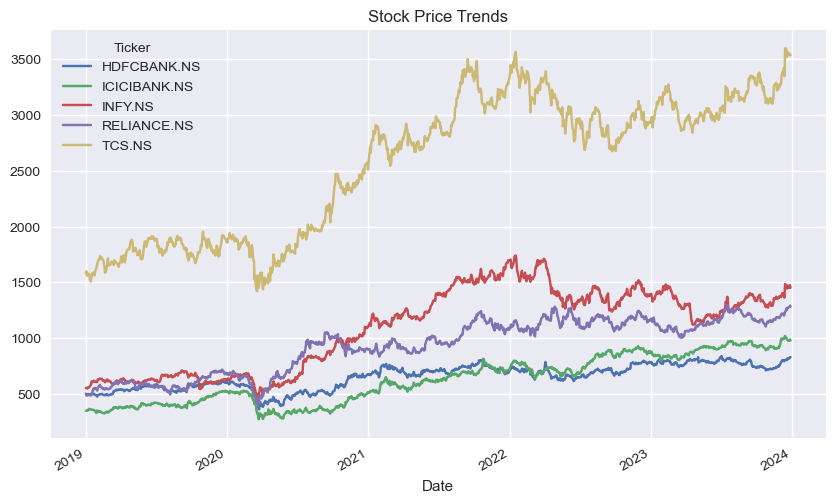

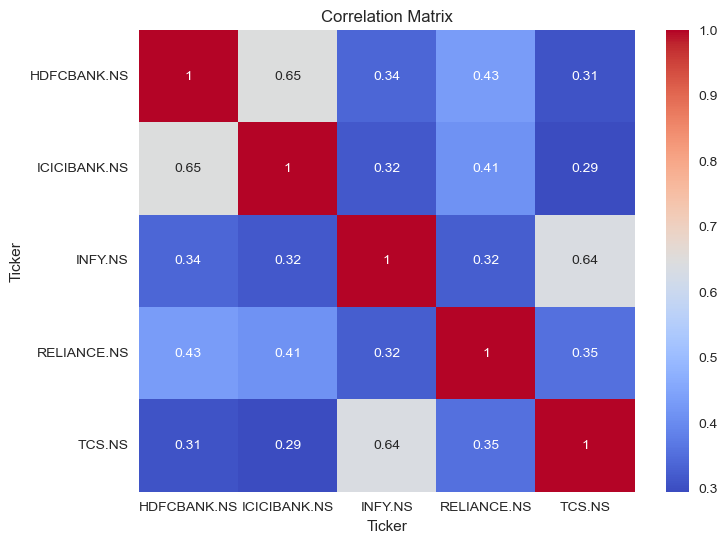

In [8]:
# Price trends
data.plot(figsize=(10,6))
plt.title("Stock Price Trends")
plt.show()

# Correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(returns.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [10]:
def portfolio_performance(weights, mean_returns, cov_matrix):
    returns = np.sum(weights * mean_returns) * 252
    std = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights))) * np.sqrt(252)
    return returns, std

In [18]:
def negative_sharpe(weights, mean_returns, cov_matrix, risk_free_rate=0.02):
    p_return, p_std = portfolio_performance(weights, mean_returns,cov_matrix)
    return -(p_return - risk_free_rate) / p_std
    

In [19]:
num_assets = len(stocks)

constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
bounds = tuple((0,1) for _ in range(num_assets))

initial_weights = num_assets * [1./num_assets]

In [22]:
optimized = minimize(negative_sharpe, initial_weights,
                     args=(mean_returns, cov_matrix),
                     method='SLSQP',
                     bounds=bounds,
                     constraints=constraints)

optimal_weights = optimized.x

In [23]:
opt_return, opt_std = portfolio_performance(optimal_weights, mean_returns, cov_matrix)

print("Optimal Portfolio Allocation:")
for stock, weight in zip(stocks, optimal_weights):
    print(f"{stock}: {round(weight*100,2)}%")

print("\nExpected Annual Return:", round(opt_return*100,2), "%")
print("Expected Risk (Volatility):", round(opt_std*100,2), "%")
print("Sharpe Ratio:", round(opt_return/opt_std,2))

Optimal Portfolio Allocation:
RELIANCE.NS: 0.0%
TCS.NS: 27.35%
INFY.NS: 28.49%
HDFCBANK.NS: 25.07%
ICICIBANK.NS: 19.09%

Expected Annual Return: 23.74 %
Expected Risk (Volatility): 21.73 %
Sharpe Ratio: 1.09


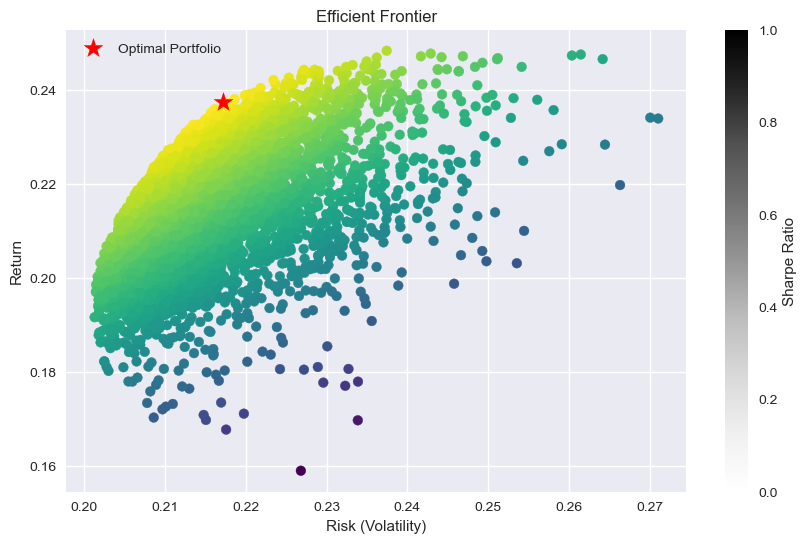

In [24]:
num_portfolios = 5000

results = np.zeros((3, num_portfolios))

for i in range(num_portfolios):
    weights = np.random.random(num_assets)
    weights /= np.sum(weights)
    p_return, p_std = portfolio_performance(weights, mean_returns, cov_matrix)
    results[0,i] = p_return
    results[1,i] = p_std
    results[2,i] = p_return / p_std

plt.figure(figsize=(10,6))
plt.scatter(results[1,:], results[0,:], c=results[2,:], cmap='viridis')

plt.scatter(opt_std, opt_return, color='red', marker='*', s=200, label='Optimal Portfolio')

plt.xlabel('Risk (Volatility)')
plt.ylabel('Return')
plt.title('Efficient Frontier')
plt.colorbar(label='Sharpe Ratio')
plt.legend()
plt.show()


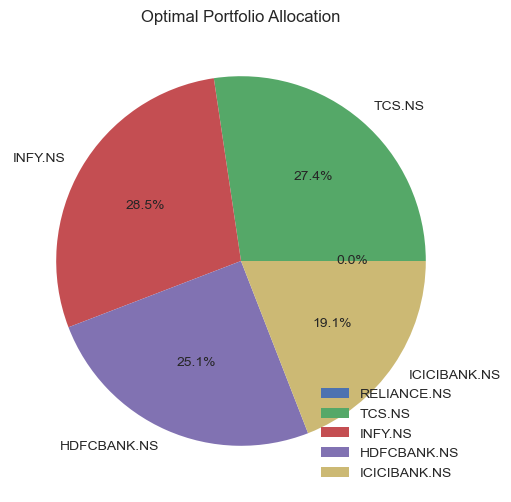

In [25]:
allocation = pd.DataFrame(optimal_weights, index=stocks, columns=['Allocation'])

allocation.plot.pie(y='Allocation', figsize=(6,6), autopct='%1.1f%%')
plt.title("Optimal Portfolio Allocation")
plt.ylabel("")
plt.show()


## 📊 Portfolio Optimization Insights

### Objective
The objective of this project was to construct an optimal portfolio using Modern Portfolio Theory by maximizing the Sharpe Ratio, balancing return and risk effectively.

---

### 🔑 Key Results

- **Expected Annual Return:** 23.74%
- **Expected Risk (Volatility):** 21.73%
- **Sharpe Ratio:** 1.09

---

### 📈 Optimal Portfolio Allocation

The optimized portfolio allocated capital as follows:

- INFY: 28.5%
- TCS: 27.4%
- HDFC Bank: 25.1%
- ICICI Bank: 19.1%
- RELIANCE: 0%

---

### 📊 Interpretation of Allocation

- The model heavily favors **technology (INFY, TCS)** and **banking stocks**, indicating they provide better risk-adjusted returns.
- **RELIANCE received 0% allocation**, suggesting that it did not contribute positively to improving the portfolio’s efficiency under the Sharpe ratio optimization.
- The allocation reflects **selective diversification**, rather than equal distribution, focusing on performance efficiency.

---

### 📉 Efficient Frontier Analysis

- The efficient frontier represents all possible portfolios for different risk-return combinations.
- Each point on the graph corresponds to a portfolio with a unique allocation of assets.
- The **optimal portfolio lies at the point with the highest Sharpe Ratio**, meaning it offers the best return per unit of risk.
- This point is identified on the graph as the **red marker**, indicating the most efficient portfolio among all simulated portfolios.

---

### 🔥 Risk-Return Tradeoff Insight

- The portfolio achieves a relatively high return (23.74%) with controlled risk (21.73%).
- A Sharpe Ratio of **1.09** indicates a strong risk-adjusted performance, meaning returns adequately compensate for the level of risk taken.

---

### 📊 Correlation (Heatmap) Insight

- The correlation matrix shows how stock returns move relative to each other.
- Lower correlation between assets improves diversification.
- The portfolio benefits from combining stocks with **less-than-perfect correlation**, reducing overall risk.

---

### 📈 Stock Price Trends Insight

- The selected stocks show upward growth trends over time, supporting their inclusion in the optimized portfolio.
- Volatility differences between stocks contribute to how weights are assigned in the portfolio.

---

### ✅ Conclusion

This project demonstrates how quantitative finance techniques can be applied to construct an optimal investment portfolio. By leveraging Modern Portfolio Theory, the model effectively balances risk and return, excludes inefficient assets, and identifies an allocation that maximizes performance efficiency.